# FoodScholar — Quickstart

Three cells from zero to a populated graph using your local corpus + pre-computed NER/NEL.

```
pip install -e '.[elastic,neo4j,ontology]'
# local services (matching the inline config below):
docker run -d -p 9200:9200 -e discovery.type=single-node \
    -e xpack.security.enabled=false elasticsearch:8.13.0
docker run -d -p 7687:7687 -p 7474:7474 \
    -e NEO4J_AUTH=neo4j/change-me neo4j:5
```

This notebook does **not** run GLiNER. Pre-computed annotations from
`data/foodscholar/ner/*.csv` are loaded and attached to the chunks — fast,
deterministic, no model downloads. The "Under the hood" appendix at the
bottom shows how to do the same end-to-end with GLiNER + HNSW when no
pre-computed output is on disk.

## 1. Configure

In [17]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from foodscholar import FoodScholar
from foodscholar.logging import configure_logging
configure_logging(level="INFO")

CORPUS_DIR = REPO_ROOT / "data" / "foodscholar" / "corpus"   # chunks_*.csv
NEL_DIR    = REPO_ROOT / "data" / "foodscholar" / "ner"      # nel_chunks_*.csv
FOODON_OWL = REPO_ROOT / "data" / "foodon.owl"

fs = FoodScholar.from_config({
    "corpus": {
        "chunks_path": str(CORPUS_DIR),
        "annotated_snapshot_path": str(REPO_ROOT / "data" / "annotated.parquet"),
    },
    "ontology": {
        "foodon_path": str(FOODON_OWL),
        "cache_path": str(REPO_ROOT / "data" / "foodon_cache.parquet"),
        "prefix_filter": ["FOODON:"],
    },
    "storage": {
        "chunk_store": {
            "backend": "elastic",
            "url": "http://localhost:9200",
            "index": "foodscholar_chunks",
        },
        "graph_store": {
            "backend": "neo4j",
            "url": "bolt://localhost:7687",
            "user": "neo4j",
            "password": "change-me",
        },
    },
})
fs.info()

{'foodscholar': '0.1.0',
 'config_hash': '2450d8c0d3958b65',
 'chunk_store': 'elastic',
 'graph_store': 'neo4j',
 'embedder': 'lazy(router:allenai/specter2_base,BAAI/bge-large-en-v1.5)',
 'llm': 'mock-llm-v0',
 'ontology': 'configured',
 'ner': 'gliner',
 'nel_backend': 'hnsw',
 'prompt_version': 'v1'}

## 2. Init stores & ingest

`fs.init()` creates the Elastic index and the Neo4j unique constraints — idempotent.

`fs.ingest(CORPUS_DIR, nel_dir=NEL_DIR)` reads every `chunks_*.csv`, attaches the matching annotations from `nel_*.csv`, and upserts to Elastic. **No GLiNER, no HNSW, no embedding** — this is fast and works without the `[annotate]` extra installed.

Chunk-text embeddings are populated in a separate step (§3) so you can iterate on annotations without re-encoding.

In [ ]:
fs.init()
meta = fs.ingest(CORPUS_DIR, nel_dir=NEL_DIR, ignore_source_types=["abstract"])
print(meta)

## 3. Embed (optional, for vector search)

Run this once chunks are in the store and you want kNN search to work. It builds the
production embedder — `SourceTypeRouter(SPECTER2 for abstracts, BGE-large for guides /
textbooks)` — lazily on the first call (~1.7 GB model load) and patches each chunk's
`embedding` + `embedding_model` fields in Elastic via a scoped `_update` (annotations untouched).

Default `only_missing=True` skips chunks that already carry a real vector, so re-runs after
adding new chunks only encode what's new.

Requires the `[annotate]` extra (`pip install -e '.[annotate]'`).

In [ ]:
meta = fs.embed()
print(meta)

## 4. Build & explore entities

Linked entities are first-class. `fs.build_entities()` walks the chunk store, dedupes every `EntityLink` by `ontology_id` (FOODON, CHEBI, GAZ, ...), aggregates `mention_count` / `chunk_count` / sample `chunk_ids`, enriches FoodOn ids with label + synonyms + ancestors from the loaded ontology, and writes everything to:

- **Elastic** — a dedicated `foodscholar_chunks_entities` index for fast lookup + search.
- **Neo4j** — `(:Entity)` nodes plus `(:Chunk)-[:MENTIONS {confidence, method}]->(:Entity)` edges.

Then `fs.entities` is the user-facing handle: `.list(prefix="FOODON")`, `.get(id)`, `.search("olive")`, `.chunks_for(id)`.

In [ ]:
meta = fs.build_entities()
print(meta)


In [ ]:
print(f"\ntotal entities: {len(fs.entities)}")
# Top FoodOn entities by chunk_count.
for ent in fs.entities.list(k=8):
    print(f"  {ent.ontology_id:24s}  {ent.label!r:40s}  chunks={ent.chunk_count}")

# Lexical search over labels + synonyms.
print("\nsearch 'olive':")
for ent in fs.entities.search("olive", k=3):
    print(f"  {ent.ontology_id}  {ent.label}")

# Reverse lookup: chunks that mention a specific entity.
top = fs.entities.list(prefix="FOODON", k=1)
if top:
    print(f"\nchunks mentioning {top[0].ontology_id} ({top[0].label}):")
    for c in fs.entities.chunks_for(top[0].ontology_id, k=3):
        print(f"  {c.chunk_id}  {c.text[:80]}")

## 5. Build Layer A (backbone)

Layer A is FoodOn (and the other OBO ontologies we link to) projected onto **your** corpus — not a copy of the raw ontology. For every FoodOn class, count how many chunks have at least one link to that class or any of its descendants, then prune ruthlessly: blacklist organizational classes, drop everything below `min_support`, lift shelves above `max_depth` to a closer ancestor, and collapse single-child chains into their leaves (recording the dropped ids in `see_also`).

Non-foods facets (`health`, `nutrients`, `dietary_patterns`, `allergies`) derive from `Mention.entity_type` on EntityLinks. The prototype's pre-computed NEL data sets every `entity_type` to `"other"`, so on this corpus those facets land as **stub roots only** — they'll fill in once chunks are re-annotated with GLiNER. Sustainability is always a stub root (no entity_type maps to it).

Layer A here is **projection only**. Chunk attachment (`fs.attach()`) is the next phase.

Re-running `fs.build_layer_a()` is idempotent: every call clears the prior `:Shelf` projection from the graph store before writing the new one, so you can re-tune `min_support` / `blacklist_terms` / `facet_overrides` freely without stale ghost shelves piling up across iterations.

In [ ]:
# Tune for the current corpus — defaults are conservative.
fs.config.layer_a.min_support = 25
fs.config.layer_a.max_depth = 6
fs.config.layer_a.collapse_single_child_chains = True

# Echo the resolved foods-facet config so the prune cascade's parameters
# are visible at a glance. Override anything per-facet via
# `fs.config.layer_a.facet_overrides["foods"] = FacetConfig(...)`.
_foods = fs.config.layer_a.resolve_facet('foods')
print(f'foods config: min_support={_foods.min_support}, max_depth={_foods.max_depth}, '
      f'collapse={_foods.collapse_single_child_chains}, '
      f'umbrella=({_foods.umbrella_direct_share_max}, {_foods.umbrella_lifted_share_min}, '
      f'min_count={_foods.umbrella_min_count}), '
      f'blacklist={_foods.blacklist_terms}')

meta = fs.build_layer_a()
print(meta)

In [ ]:
from collections import Counter

shelves = fs.graph_store.list_shelves()
by_facet = Counter(s.facet for s in shelves)
print('shelves per facet:')
for facet, n in sorted(by_facet.items(), key=lambda kv: -kv[1]):
    print(f'  {facet:18s} {n}')

foods = [s for s in shelves if s.facet == 'foods']
print(f'\ntop 10 foods shelves by chunk_count:')
for s in sorted(foods, key=lambda s: -s.chunk_count)[:10]:
    direct_share = s.support_direct / s.chunk_count if s.chunk_count else 0
    print(f'  {s.label[:40]:40s}  {s.chunk_count:>5d}  (direct={s.support_direct} lifted={s.support_lifted} direct_share={direct_share:.3f})')

print(f'\nbottom 5 surviving foods shelves:')
for s in sorted(foods, key=lambda s: s.chunk_count)[:5]:
    print(f'  {s.label[:40]:40s}  {s.chunk_count:>5d}')

depths = Counter(s.depth for s in foods)
print(f'\nfoods depth distribution:')
for d in sorted(depths):
    print(f'  depth {d}: {depths[d]}')

# Inflation diagnostic — shelves whose support is mostly lifted (per the spec,
# >0.9 means a deep dense subtree funneled into one ancestor). After the
# umbrella rule lands these should be rare — surviving inflated shelves are
# real navigation roots (e.g. `food product` itself) rather than scaffolding.
inflated = [s for s in foods if s.chunk_count > 0 and s.support_lifted / s.chunk_count > 0.9]
if inflated:
    print(f'\n{len(inflated)} potentially-inflated shelves (support_lifted/chunk_count > 0.9):')
    for s in sorted(inflated, key=lambda s: -s.chunk_count)[:5]:
        ratio = s.support_lifted / s.chunk_count
        direct_share = s.support_direct / s.chunk_count
        print(f'  {s.label[:40]:40s}  lifted_ratio={ratio:.2f}  direct_share={direct_share:.3f}  count={s.chunk_count}')
else:
    print('\nno inflation flags.')

# Orphan diagnostic — shelves at depth 0 that aren't the stub roots. After
# the umbrella rule lands these are the navigation roots that no surviving
# parent could be found for. Whitelisting the foods root (FOODON:00001002)
# typically reduces this to 1-2.
depth0_foods = [s for s in foods if s.depth == 0]
print(f'\n{len(depth0_foods)} foods shelves at depth 0 (roots):')
for s in sorted(depth0_foods, key=lambda s: -s.chunk_count)[:10]:
    print(f'  {s.label[:40]:40s}  count={s.chunk_count}  foodon_id={s.foodon_id}')

### 5b. Why these thresholds? — parameter sweep

The three knobs the prune cascade exposes (`min_support`, `umbrella_direct_share_max`, `umbrella_min_count`) are empirical, not derived. This cell sweeps each one independently against the live corpus and plots the trade-off curves, then a 2D heatmap of the two umbrella knobs together. The chosen values are marked.

Cheap: support is collected once over the chunk store, then `prune(...)` re-runs per config combo without touching Neo4j. Runs in seconds even on a multi-thousand-chunk corpus.

In [ ]:
import matplotlib.pyplot as plt
from foodscholar.layer_a.propagate import collect_support
from foodscholar.layer_a.prune import prune
from foodscholar.config import FacetConfig, LayerAConfig

# Collect support once — every sweep point re-prunes against this in-memory
# table. ~seconds for ~13k chunks; the bottleneck would be Neo4j writes,
# which we skip.
def _chunk_iter():
    for batch in fs.chunk_store.iter_chunks():
        yield from batch

base = fs.config.layer_a.resolve_facet('foods')
support = collect_support(_chunk_iter(), fs.ontology,
                          min_link_confidence=base.min_link_confidence,
                          facet='foods')
print(f'support table: {len(support.with_descendants)} terms, '
      f'{sum(support.direct.values())} direct mentions')

def _resolve_with(**overrides):
    """Build a fully-resolved foods FacetConfig by overlaying overrides on the
    live `fs.config.layer_a`. Goes through `resolve_facet` so we touch only the
    public config surface."""
    base_cfg = fs.config.layer_a
    layer_a = LayerAConfig.model_validate(base_cfg.model_dump())
    layer_a.facet_overrides = dict(layer_a.facet_overrides)
    layer_a.facet_overrides['foods'] = FacetConfig(**overrides)
    return layer_a.resolve_facet('foods')

def _summarize(shelves: list) -> dict:
    inflated = sum(1 for s in shelves
                   if s.chunk_count > 0 and s.support_lifted / s.chunk_count > 0.9)
    roots = sum(1 for s in shelves if s.parent_shelf_id is None)
    return {'n_shelves': len(shelves), 'n_inflated': inflated, 'n_roots': roots}

# Run the three single-knob sweeps.
ms_grid = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200]
ds_grid = [0.0, 0.03, 0.05, 0.075, 0.10, 0.125, 0.15, 0.20, 0.30, 0.50]
mc_grid = [10, 25, 50, 75, 100, 150, 200, 300, 500, 1000]

ms_data = [(ms, _summarize(prune(support, fs.ontology, _resolve_with(min_support=ms), 'foods'))) for ms in ms_grid]
ds_data = [(ds, _summarize(prune(support, fs.ontology, _resolve_with(umbrella_direct_share_max=ds), 'foods'))) for ds in ds_grid]
mc_data = [(mc, _summarize(prune(support, fs.ontology, _resolve_with(umbrella_min_count=mc), 'foods'))) for mc in mc_grid]

# ----- Plot -----
plt.rcParams.update({
    'font.family': ['DejaVu Sans', 'Helvetica Neue', 'Helvetica', 'Arial', 'sans-serif'],
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#9CA3AF',
    'axes.labelcolor': '#374151',
    'xtick.color': '#6B7280',
    'ytick.color': '#6B7280',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
fig.patch.set_facecolor('white')

SHELVES_COLOR = '#2563EB'   # blue — the good metric
INFLATED_COLOR = '#DC2626'  # red  — the bad metric
CHOSEN_COLOR = '#059669'    # green — the picked value

def _plot(ax, data, knob_name, subtitle, chosen, log_x=False):
    xs = [d[0] for d in data]
    n_shelves = [d[1]['n_shelves'] for d in data]
    n_inflated = [d[1]['n_inflated'] for d in data]

    ax.plot(xs, n_shelves, 'o-', label='surviving shelves',
            color=SHELVES_COLOR, linewidth=2.2, markersize=6, markeredgewidth=0)
    ax.plot(xs, n_inflated, 's--', label='inflated (>0.9 lifted)',
            color=INFLATED_COLOR, linewidth=1.6, markersize=5, alpha=0.85, markeredgewidth=0)

    # Marker dot at the chosen value on each curve.
    if chosen in xs:
        i = xs.index(chosen)
        for y, c in [(n_shelves[i], SHELVES_COLOR), (n_inflated[i], INFLATED_COLOR)]:
            ax.plot(chosen, y, 'o', markersize=12, markerfacecolor='none',
                    markeredgecolor=CHOSEN_COLOR, markeredgewidth=2.2)

    ax.axvline(chosen, color=CHOSEN_COLOR, linestyle=':', linewidth=1.6, alpha=0.6)
    ax.annotate(f'chosen = {chosen}', xy=(chosen, max(n_shelves) * 1.02),
                color=CHOSEN_COLOR, fontsize=9.5, fontweight='semibold',
                ha='left', va='bottom',
                xytext=(8, 0), textcoords='offset points')

    ax.set_title(f'{knob_name}', loc='left', pad=14)
    # Subtitle below the title using ax.text
    ax.text(0.0, 1.02, subtitle, transform=ax.transAxes,
            fontsize=9.5, color='#6B7280', ha='left', va='bottom', style='italic')
    ax.set_xlabel(f'{knob_name} (lower ←  → higher)')
    ax.set_ylabel('shelves')
    ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.6)
    if log_x:
        ax.set_xscale('log')
    ax.legend(loc='best', fontsize=9, frameon=False)

_plot(axes[0], ms_data, 'min_support',
      'threshold floor — shelves with fewer chunks get pruned',
      base.min_support, log_x=True)
_plot(axes[1], ds_data, 'umbrella_direct_share_max',
      'aggressiveness — drops shelves with low direct-share',
      base.umbrella_direct_share_max)
_plot(axes[2], mc_data, 'umbrella_min_count',
      'size guard — exempts small shelves from the umbrella rule',
      base.umbrella_min_count, log_x=True)

fig.suptitle('Layer A — single-knob parameter sweep', fontsize=14, fontweight='semibold',
             y=1.04, x=0.02, ha='left')
fig.text(0.02, 0.985,
         'Pruning the foods facet · goal: maximize surviving shelves (blue) '
         'while minimizing inflated ones (red)',
         fontsize=10.5, color='#4B5563', ha='left', va='top')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print the chosen-point summary as numeric grounding for the chart.
chosen_cfg = _resolve_with()  # all defaults
chosen_shelves = prune(support, fs.ontology, chosen_cfg, 'foods')
chosen = _summarize(chosen_shelves)
print(f"\nat chosen config (min_support={base.min_support}, "
      f"direct_share_max={base.umbrella_direct_share_max}, "
      f"min_count={base.umbrella_min_count}):")
print(f"  shelves:               {chosen['n_shelves']}")
print(f"  inflated (>0.9 lifted): {chosen['n_inflated']}")
print(f"  orphan roots:           {chosen['n_roots']}")

In [ ]:
import numpy as np

# Joint sweep: direct_share_max × min_count. Heatmap colors the joint effect.
ds_axis = [0.03, 0.05, 0.075, 0.10, 0.125, 0.15, 0.20, 0.30]
mc_axis = [25, 50, 75, 100, 150, 200, 300, 500]

grid_shelves = np.zeros((len(mc_axis), len(ds_axis)))
grid_inflated = np.zeros((len(mc_axis), len(ds_axis)))
for i, mc in enumerate(mc_axis):
    for j, ds in enumerate(ds_axis):
        cfg = _resolve_with(umbrella_direct_share_max=ds, umbrella_min_count=mc)
        shelves = prune(support, fs.ontology, cfg, 'foods')
        s = _summarize(shelves)
        grid_shelves[i, j] = s['n_shelves']
        grid_inflated[i, j] = s['n_inflated']
clean = grid_shelves - grid_inflated

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8))
fig.patch.set_facecolor('white')
plt.subplots_adjust(wspace=0.28)

def _heatmap(ax, grid, cmap, title, subtitle, fmt='{:.0f}', invert_text=None):
    im = ax.imshow(grid, aspect='auto', origin='lower', cmap=cmap)
    ax.set_xticks(range(len(ds_axis)))
    ax.set_xticklabels([f'{d:g}' for d in ds_axis], fontsize=9.5)
    ax.set_yticks(range(len(mc_axis)))
    ax.set_yticklabels(mc_axis, fontsize=9.5)
    ax.set_xlabel('umbrella_direct_share_max  (lower = more aggressive)',
                  fontsize=10, labelpad=8, color='#374151')
    ax.set_ylabel('umbrella_min_count  (lower = guards fewer shelves)',
                  fontsize=10, labelpad=8, color='#374151')
    ax.set_title(title, loc='left', pad=14, fontsize=12, fontweight='semibold')
    ax.text(0.0, 1.02, subtitle, transform=ax.transAxes,
            fontsize=9.5, color='#6B7280', ha='left', va='bottom', style='italic')
    ax.tick_params(axis='both', which='both', length=0)
    cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(labelsize=9, length=0, color='#6B7280')
    # Cell annotations with auto-contrast text color.
    vmax = grid.max() if grid.max() > 0 else 1
    for i in range(len(mc_axis)):
        for j in range(len(ds_axis)):
            v = grid[i, j]
            if invert_text is not None:
                use_white = invert_text(v, vmax)
            else:
                use_white = v < vmax * 0.55
            ax.text(j, i, fmt.format(v), ha='center', va='center',
                    color='#FFFFFF' if use_white else '#111827',
                    fontsize=8.5, fontweight='medium')
    return im

_heatmap(axes[0], clean, 'viridis',
         'Clean shelves',
         'surviving − inflated · higher (brighter) is better',
         invert_text=lambda v, vmax: v < vmax * 0.55)
_heatmap(axes[1], grid_inflated, 'Reds',
         'Inflated shelves',
         'pure scaffolding that slipped through · lower (paler) is better',
         invert_text=lambda v, vmax: v > vmax * 0.55)

# Mark the chosen config in both heatmaps.
if base.umbrella_direct_share_max in ds_axis and base.umbrella_min_count in mc_axis:
    j_chosen = ds_axis.index(base.umbrella_direct_share_max)
    i_chosen = mc_axis.index(base.umbrella_min_count)
    for ax in axes:
        ax.add_patch(plt.Rectangle((j_chosen - 0.5, i_chosen - 0.5), 1, 1,
                                   fill=False, edgecolor='#F59E0B',
                                   linewidth=3.2, linestyle='-'))
        ax.annotate('chosen', xy=(j_chosen, i_chosen),
                    xytext=(j_chosen + 0.55, i_chosen + 0.55),
                    fontsize=9, fontweight='semibold', color='#F59E0B',
                    ha='left', va='center')

fig.suptitle('Layer A — joint sweep of the two umbrella knobs',
             fontsize=14, fontweight='semibold', y=1.04, x=0.02, ha='left')
fig.text(0.02, 0.99,
         f'Pruning the foods facet · gold box = chosen config '
         f'(direct_share_max={base.umbrella_direct_share_max}, '
         f'min_count={base.umbrella_min_count})',
         fontsize=10.5, color='#4B5563', ha='left', va='top')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 5c. Why does so much support land at the synthetic root? — NEL coverage audit

The synthetic `Foods` root carries `support_lifted = chunk_count` by construction — every chunk reaching the facet contributes through lifting since nothing in any ontology resolves to the root itself. But the *size* of that number relative to the total corpus is informative: a high root count means many chunks failed to find a specific shelf, either because they have no FOODON links at all, or because all their links got umbrella-pruned.

This cell walks the chunk store once and reports:

- **NEL coverage**: how many chunks have ≥1 `foodon_id`, how many have only non-FOODON `entity_links`, how many have no links at all.
- **Sample of zero-foodon chunks**: 5 random texts so you can eyeball whether they're nutrition-y-but-not-food (expected) or food-content-the-NEL-missed (a real coverage gap).

In [ ]:
import random
from collections import Counter

n_total = 0
n_with_foodon = 0
n_only_other_obo = 0  # has entity_links but zero FOODON ids
n_no_links = 0
prefix_counter: Counter = Counter()
zero_foodon_samples: list = []

for batch in fs.chunk_store.iter_chunks():
    for chunk in batch:
        n_total += 1
        has_foodon = bool(chunk.foodon_ids)
        has_any_link = bool(chunk.entity_links)
        if has_foodon:
            n_with_foodon += 1
        elif has_any_link:
            n_only_other_obo += 1
            for link in chunk.entity_links:
                oid = link.ontology_id
                prefix = oid.split(':', 1)[0] if ':' in oid else '(none)'
                prefix_counter[prefix] += 1
        else:
            n_no_links += 1

        # Keep a reservoir sample of zero-foodon chunks for hand inspection.
        if not has_foodon and len(zero_foodon_samples) < 200:
            zero_foodon_samples.append(chunk)

print(f'chunks total:                  {n_total:>6d}  (100.0%)')
print(f'  ≥1 FOODON id (well-placed):  {n_with_foodon:>6d}  ({100*n_with_foodon/n_total:>5.1f}%)')
print(f'  only non-FOODON entity_links: {n_only_other_obo:>6d}  ({100*n_only_other_obo/n_total:>5.1f}%)')
print(f'  zero entity links at all:     {n_no_links:>6d}  ({100*n_no_links/n_total:>5.1f}%)')

print(f'\nontology prefixes seen on chunks WITHOUT a FOODON id ({len(prefix_counter)} distinct):')
for prefix, n in prefix_counter.most_common(10):
    print(f'  {prefix:15s}  {n:>6d}')

print(f'\n5 random zero-foodon chunk texts (hand-check whether they should have had a FOODON link):')
random.seed(0)
for chunk in random.sample(zero_foodon_samples, k=min(5, len(zero_foodon_samples))):
    has_other = bool(chunk.entity_links)
    marker = '  [has non-FOODON links]' if has_other else '  [no links at all]'
    print(f'\n  {chunk.chunk_id}{marker}')
    print(f'    {chunk.text[:240].replace(chr(10), " ")}{"..." if len(chunk.text) > 240 else ""}')

### 5d. Sanity gate — 50 random FOODON-linked chunks

Pick 50 random chunks that have ≥1 FOODON link and print the text + the projected shelf labels each one rolls up to. The shelves shown are what `fs.attach()` will write once it's implemented — for every `foodon_id` on the chunk, this finds the deepest surviving shelf whose `foodon_id` is that term OR a surviving ancestor of it.

Read 5–10 of these by hand. The question to answer: **is each chunk genuinely about the shelf it lands on?** Common failure modes to look for:
- NEL drift: a chunk mentioning "milky way" got linked to `cow milk`.
- Over-broad attachment: a chunk explicitly about kale ends up on `vegetable` instead of `kale` because the more specific shelf got pruned.
- Off-topic match: text is about cardiology but linked to `fat` via "fat embolism".

In [ ]:
import random

# Index surviving shelves by foodon_id for O(1) projection lookup.
shelves = fs.graph_store.list_shelves()
shelf_by_foodon = {s.foodon_id: s for s in shelves if s.foodon_id is not None}

def project_to_shelves(foodon_ids):
    """For each foodon_id, walk up via ontology ancestors until a surviving
    shelf is found. Returns the set of distinct deepest-surviving shelf labels.
    Mirrors what fs.attach() will compute once it lands."""
    out = set()
    for fid in foodon_ids:
        # Self first (deepest possible match).
        if fid in shelf_by_foodon:
            out.add(shelf_by_foodon[fid].label)
            continue
        # Walk ancestors; pick the deepest surviving one.
        ancestors = fs.ontology.id_to_ancestors(fid) if fs.ontology else []
        best = None
        best_depth = -1
        for anc in ancestors:
            sh = shelf_by_foodon.get(anc)
            if sh is not None and sh.depth > best_depth:
                best = sh
                best_depth = sh.depth
        if best is not None:
            out.add(best.label)
    return sorted(out)

# Collect chunks with ≥1 FOODON id, then sample 50 uniformly.
candidates = []
for batch in fs.chunk_store.iter_chunks():
    for chunk in batch:
        if chunk.foodon_ids:
            candidates.append(chunk)
        if len(candidates) >= 5000:  # cap upstream sampling cost
            break
    if len(candidates) >= 5000:
        break

random.seed(0)  # reproducible audit
sample = random.sample(candidates, k=min(50, len(candidates)))
print(f'sampled {len(sample)} of {len(candidates)} FOODON-linked chunks scanned\n')

for i, chunk in enumerate(sample[:10]):  # show first 10 by default; raise to [:50] for full audit
    foodon_labels = [fs.ontology.id_to_label(fid) or fid for fid in chunk.foodon_ids[:5]]
    projected = project_to_shelves(chunk.foodon_ids)
    print(f'[{i+1}] {chunk.chunk_id}')
    print(f'    foodon_ids ({len(chunk.foodon_ids)}): {foodon_labels}{" ..." if len(chunk.foodon_ids) > 5 else ""}')
    print(f'    projected shelves: {projected}')
    text = chunk.text.replace("\n", " ")
    print(f'    text: {text[:220]}{"..." if len(text) > 220 else ""}')
    print()

### 5e. Sanity gate — 20 chunks with non-FOODON links only

These are the chunks that reached the foods facet only via the synthetic root (no FOODON id, but ≥1 entity_link of some other prefix). The question: **does the text contain a food term that should have linked but didn't?** That's a NEL coverage gap — the upstream linker missed a food mention.

If 5+ of 20 sampled chunks have an obvious missed food term, re-annotation with GLiNER is the right next step. If most are nutrition-y-but-not-food (papers about "macronutrient distribution", clinical population studies, etc.), the synthetic-root lift is expected and harmless.

In [ ]:
candidates_nonfoodon = []
for batch in fs.chunk_store.iter_chunks():
    for chunk in batch:
        if not chunk.foodon_ids and chunk.entity_links:
            candidates_nonfoodon.append(chunk)
        if len(candidates_nonfoodon) >= 5000:
            break
    if len(candidates_nonfoodon) >= 5000:
        break

random.seed(1)
sample_nf = random.sample(candidates_nonfoodon, k=min(20, len(candidates_nonfoodon)))
print(f'sampled {len(sample_nf)} of {len(candidates_nonfoodon)} non-FOODON-only chunks scanned\n')

for i, chunk in enumerate(sample_nf):
    surface_forms = [link.mention.text for link in chunk.entity_links[:5]]
    prefixes = sorted({link.ontology_id.split(':', 1)[0] for link in chunk.entity_links})
    print(f'[{i+1}] {chunk.chunk_id}')
    print(f'    linked mentions ({len(chunk.entity_links)}): {surface_forms}{" ..." if len(chunk.entity_links) > 5 else ""}')
    print(f'    prefixes seen: {prefixes}')
    text = chunk.text.replace("\n", " ")
    print(f'    text: {text[:260]}{"..." if len(text) > 260 else ""}')
    print()

## 6. Inspect


In [ ]:
# A handful of chunks with their attached mentions / foodon ids.
for c in fs.chunk_store.scan()[:3]:
    print(f"\n[{c.chunk_id}] {c.source_type} — {c.text[:80]}...")
    print(f"  mentions:   {[m.text for m in c.mentions[:6]]}")
    print(f"  foodon_ids: {c.foodon_ids[:6]}")
    other = sorted({ln.ontology_id for ln in c.entity_links if not ln.ontology_id.startswith('FOODON:')})
    print(f"  other_links: {other[:6]}")

# BM25 round-trip against Elastic.
hits = fs.chunk_store.search("olive oil", k=3, use_vector=False)
print("\n'olive oil' top 3:")
for h in hits:
    print(f"  {h.chunk_id}  {h.text[:80]}")

## 7. Visualize

`fs.viz` builds typed graphs (`VizGraph`) at five abstraction levels and renders
them via pluggable backends. Requires the `[viz]` extra (`pip install -e '.[viz]'`).

| Level | Method                                  | What it shows |
| ----- | --------------------------------------- | ------------- |
| L0    | `fs.viz.entity_histogram(prefix=, k=)`  | Top-k entities by chunk_count (stats) |
| L1    | `fs.viz.entity_neighborhood(ontology_id)` | One entity + mentioning chunks + co-entities |
| L2    | `fs.viz.shelf(shelf_id)`                | One Layer A shelf + themes + chunks |
| L3    | `fs.viz.backbone(facet=)`               | Whole Layer A/B/C backbone |
| L4    | `fs.viz.ontology_subtree(ontology_id)`  | FoodOn ancestors + descendants |

Renderer choice via `.render(backend, output=...)`:
- `"pyvis"`      → interactive HTML (best in-notebook).
- `"cytoscape"`  → self-contained Cytoscape.js HTML, no Python deps beyond stdlib.
- `"graphviz"`   → static SVG / PNG (needs `dot` binary).
- `"matplotlib"` → bars / heatmaps over node weights (ignores edges; perfect for L0).

POST http://localhost:9200/foodscholar_chunks_entities/_search [status:200 duration:0.010s]
POST http://localhost:9200/foodscholar_chunks_entities/_search [status:200 duration:0.007s]
POST http://localhost:9200/foodscholar_chunks_entities/_search [status:200 duration:0.007s]
POST http://localhost:9200/foodscholar_chunks_entities/_search [status:200 duration:0.005s]
POST http://localhost:9200/foodscholar_chunks_entities/_search [status:200 duration:0.005s]
POST http://localhost:9200/foodscholar_chunks_entities/_search [status:200 duration:0.005s]
POST http://localhost:9200/foodscholar_chunks_entities/_search [status:200 duration:0.004s]
POST http://localhost:9200/foodscholar_chunks_entities/_search [status:200 duration:0.004s]
POST http://localhost:9200/foodscholar_chunks_entities/_search [status:200 duration:0.003s]


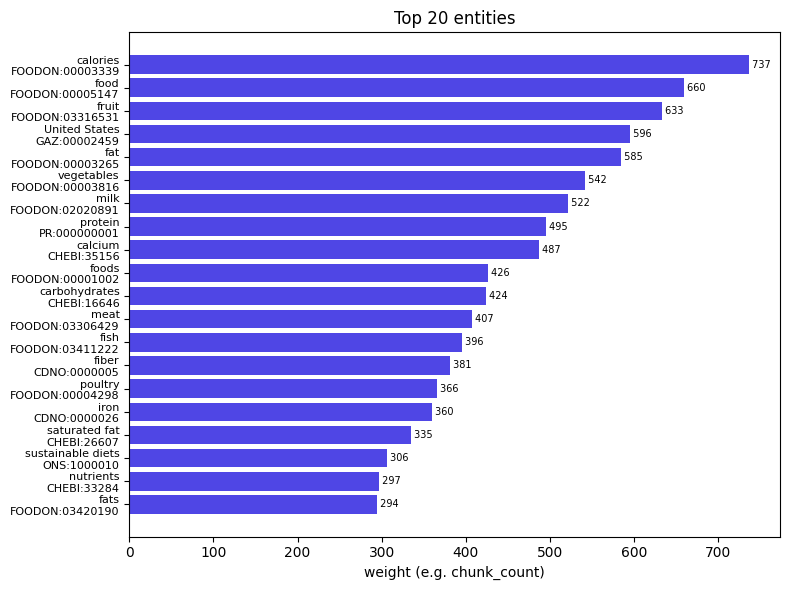

In [ ]:
# L0 — top entities, rendered with matplotlib (inline figure).
fig = fs.viz.entity_histogram(k=20).render("matplotlib")

In [ ]:
# L1 — entity neighborhood. Render to an HTML string and inline it via
# IPython.display.HTML(). Earlier we wrote the HTML to a file and embedded
# via IFrame(src=...) — VS Code's notebook webview can't fetch local files
# from a relative path, so the iframe stayed empty. Inline HTML works in
# every notebook environment.
from IPython.display import HTML

top = fs.entities.list(prefix='FOODON', k=1)
anchor_id = top[0].ontology_id if top else 'FOODON:03309927'

html = fs.viz.entity_neighborhood(anchor_id, max_chunks=8).render('cytoscape')
HTML(html)

In [ ]:
# L4 — ontology subtree around a single FoodOn id. Inline HTML, same
# recipe as L1.
from IPython.display import HTML

# Top entities by chunk_count are often leaves in the FoodOn hierarchy (e.g.
# `food calorie datum`) — picking one of those produces a 1-edge subtree.
# Walk the top-50 and prefer anchors with real downward structure: ≥ 3
# descendants ideally, then ≥ 1, then whatever's left.
_onto = fs.ontology
_top = [e.ontology_id for e in fs.entities.list(prefix='FOODON', k=50)]
_resolved = [(oid, len(_onto.id_to_descendants(oid)))
             for oid in _top if _onto.get(oid) is not None]
subtree_id = next((oid for oid, n in _resolved if n >= 3),
                  next((oid for oid, n in _resolved if n >= 1),
                       _resolved[0][0] if _resolved else anchor_id))
if subtree_id != anchor_id:
    n_desc = dict(_resolved).get(subtree_id, 0)
    print(f'L4 anchor: {subtree_id} ({n_desc} descendants) — L1 anchor {anchor_id} was a leaf or unresolved')

rg_subtree = fs.viz.ontology_subtree(subtree_id, max_descendants=20)
print(rg_subtree)

html = rg_subtree.render('cytoscape')
HTML(html)

In [ ]:
# L2 (Layer A backbone, foods facet). Inline HTML, same recipe as L1.
from IPython.display import HTML

rg_backbone = fs.viz.backbone(facet='foods')
print(rg_backbone)

html = rg_backbone.render('cytoscape')
HTML(html)

---

## Under the hood (appendix)

The three cells above are everything an end-user needs. The appendix below is
for contributors and shows the same pipeline **without** pre-computed NER/NEL —
i.e. running GLiNER + HNSW from scratch. Skip it unless you're debugging the
NER side.

### A1. Run GLiNER + HNSW directly

Requires `pip install -e '.[annotate]'`. First call downloads the GLiNER bio
model (~1.5 GB) and the BioLORD encoder (~440 MB), then builds and caches the
FoodOn HNSW index under `data/`. Subsequent runs are fast.

In [ ]:
import importlib.util as _u

needs = [pkg for pkg in ("gliner", "hnswlib", "sentence_transformers") if not _u.find_spec(pkg)]
if needs:
    print("Skipping — missing:", needs, "\nInstall with:  pip install -e '.[annotate]'")
else:
    fs_g = FoodScholar.from_config({
        "corpus": {"chunks_path": str(CORPUS_DIR)},
        "ontology": {
            "foodon_path": str(FOODON_OWL),
            "cache_path": str(REPO_ROOT / "data" / "foodon_cache.parquet"),
            "prefix_filter": ["FOODON:"],
        },
        "storage": {
            "chunk_store": {"backend": "memory"},
            "graph_store": {"backend": "memory"},
        },
    })
    one_file = next(iter(sorted(CORPUS_DIR.glob("*.csv"))))
    fs_g.ingest(one_file)  # no nel_dir → GLiNER + HNSW path
    c = fs_g.chunk_store.scan()[0]
    print(c.chunk_id, "mentions:", [m.text for m in c.mentions[:6]])

### A2. Inspect the graph

Layer B/C builders are still stubs — this appendix shows the `fs.graph` API
the builders will write through. Run it against the in-memory facade so it
doesn't depend on the live services.

In [ ]:
fs_local = FoodScholar.in_memory()
fs_local.graph.add_shelf(shelf_id="s-med", label="Mediterranean diet",
                         facet="dietary_patterns", depth=0)
fs_local.graph.add_theme(theme_id="t-olive", label="Olive oil benefits",
                         shelf_ids=["s-med"], discovered_by="leiden",
                         discovery_version="nb")
shelf = fs_local.graph.shelf("s-med")
print("shelf :", shelf.label, "| facet:", shelf.facet)
print("themes:", [t.label for t in shelf.themes()])